Dataset:
   study_hours  attendance  previous_marks  assignments_completed  final_score
0            2          60              50                      4           55
1            4          75              65                      6           68
2            6          85              78                      8           80
3            8          90              88                      9           92
4            1          50              40                      2           45
5            5          80              70                      7           75
6            7          95              92                     10           96
7            3          65              55                      5           60
8            9          98              95                     10           99
9            4          70              60                      6           65

Features:
   study_hours  attendance  previous_marks  assignments_completed
0            2          60              50   

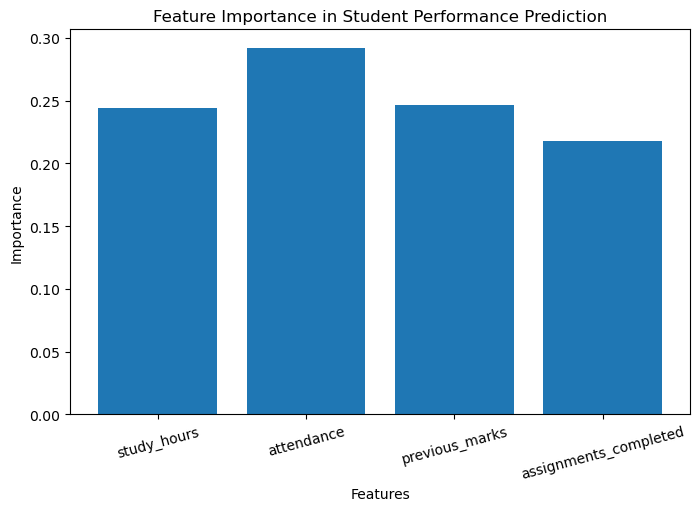


Model Saved Successfully!


In [1]:
# STUDENT PERFORMANCE PREDICTION ML MODEL
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt

# DATASET

data = {
    "study_hours": [2,4,6,8,1,5,7,3,9,4],
    "attendance": [60,75,85,90,50,80,95,65,98,70],
    "previous_marks": [50,65,78,88,40,70,92,55,95,60],
    "assignments_completed": [4,6,8,9,2,7,10,5,10,6],
    "final_score": [55,68,80,92,45,75,96,60,99,65]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Show dataset
print("Dataset:")
print(df)

#  FEATURES AND TARGET

X = df.drop("final_score", axis=1)

y = df["final_score"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

# SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Size:", len(X_train))
print("Testing Data Size:", len(X_test))

# CREATE MODEL
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

#  TRAIN MODEL

model.fit(X_train, y_train)

print("\nModel Training Completed!")

#  MAKE PREDICTIONS

predictions = model.predict(X_test)

print("\nPredictions:")
print(predictions)

#EVALUATE MODEL

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("\nMean Absolute Error:", round(mae, 2))

print("R2 Score:", round(r2, 2))

# TEST CUSTOM STUDENT

student = pd.DataFrame({
    "study_hours": [6],
    "attendance": [85],
    "previous_marks": [75],
    "assignments_completed": [8]
})

predicted_score = model.predict(student)

print("\nPredicted Student Score:")

print(round(predicted_score[0], 2))

# FEATURE IMPORTANCE
importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
})

print("\nFeature Importance:")
print(importance_df)

# graphs and charts

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance in Student Performance Prediction")

plt.xticks(rotation=15)

plt.show()

#  SAVE MODEL

import joblib

joblib.dump(model, "student_performance_model.pkl")

print("\nModel Saved Successfully!")
